# Customer 360 — Machine Learning Workshop

This notebook covers EDA, churn classification, 12-month revenue prediction, customer segmentation, PCA, anomaly detection, and a final Customer 360 output.

**Important:** `CustomerID` is an identifier and is never used as a model feature. `Future12MRevenueEGP` is a future outcome and is excluded from current churn prediction to avoid target leakage.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder

from sklearn.model_selection import train_test_split,GridSearchCV,StratifiedKFold,KFold,cross_val_score,cross_val_predict

from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier,RandomForestRegressor,GradientBoostingRegressor,IsolationForest

from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,confusion_matrix,roc_curve,mean_absolute_error,mean_squared_error,r2_score,silhouette_score,adjusted_rand_score

from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTENC

In [2]:
df = pd.read_csv("../Dataset/customer_360_ml_workshop.csv")
df.shape

(3000, 16)

### A. Data Understanding

In [3]:
df.head()

,CustomerID,Age,Region,TenureMonths,ContractType,InternetType,MonthlyUsageGB,MonthlyChargeEGP,NumServices,SupportCalls6M,LatePayments12M,PaperlessBilling,AutoPay,SatisfactionScore,Future12MRevenueEGP,Churn
0,CUST-00001,22,Alexandria,23,Month-to-month,DSL,317.9,580.48,5,5,0,Yes,Yes,5.0,6287.08,Yes
1,CUST-00002,59,Upper Egypt,9,Month-to-month,4G/5G,359.3,434.36,1,1,1,No,Yes,4.0,4619.91,No
2,CUST-00003,52,Giza,21,Month-to-month,DSL,176.9,391.35,3,5,1,Yes,Yes,5.0,4512.25,No
3,CUST-00004,41,Giza,12,Month-to-month,DSL,312.5,420.40,3,2,1,No,Yes,5.0,3809.65,No
4,CUST-00005,40,Delta,21,Month-to-month,4G/5G,191.6,462.73,3,4,0,No,Yes,3.0,4731.09,No


In [4]:
df.tail()

,CustomerID,Age,Region,TenureMonths,ContractType,InternetType,MonthlyUsageGB,MonthlyChargeEGP,NumServices,SupportCalls6M,LatePayments12M,PaperlessBilling,AutoPay,SatisfactionScore,Future12MRevenueEGP,Churn
2995,CUST-02996,51,Giza,14,One year,4G/5G,257.8,530.46,4,2,2,Yes,Yes,2.0,6353.49,No
2996,CUST-02997,33,Giza,36,Two year,Fiber,158.8,438.19,2,4,0,Yes,Yes,4.0,5956.22,No
2997,CUST-02998,36,Giza,20,Month-to-month,DSL,351.5,569.98,5,3,0,Yes,Yes,4.0,6233.85,No
2998,CUST-02999,41,Delta,4,One year,DSL,130.4,459.19,5,1,0,Yes,Yes,4.0,5590.18,Yes
2999,CUST-03000,53,Delta,1,Month-to-month,Fiber,269.5,379.02,2,2,1,No,Yes,4.0,2777.75,No


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CustomerID           3000 non-null   str    
 1   Age                  3000 non-null   int64  
 2   Region               3000 non-null   str    
 3   TenureMonths         3000 non-null   int64  
 4   ContractType         3000 non-null   str    
 5   InternetType         2955 non-null   str    
 6   MonthlyUsageGB       2925 non-null   float64
 7   MonthlyChargeEGP     3000 non-null   float64
 8   NumServices          3000 non-null   int64  
 9   SupportCalls6M       3000 non-null   int64  
 10  LatePayments12M      3000 non-null   int64  
 11  PaperlessBilling     3000 non-null   str    
 12  AutoPay              3000 non-null   str    
 13  SatisfactionScore    2940 non-null   float64
 14  Future12MRevenueEGP  3000 non-null   float64
 15  Churn                3000 non-null   str    
dtyp

In [6]:
df.describe()

,Age,TenureMonths,MonthlyUsageGB,MonthlyChargeEGP,NumServices,SupportCalls6M,LatePayments12M,SatisfactionScore,Future12MRevenueEGP
count,3000.000000,3000.000000,2925.000000,3000.000000,3000.000000,3000.000000,3000.000000,2940.000000,3000.000000
mean,44.057667,25.540667,230.132855,487.345707,3.515000,2.206333,1.111000,3.486054,5361.156050
std,15.346319,16.525739,89.357331,118.451753,1.714085,1.503722,1.066016,1.013758,1479.868751
min,18.000000,1.000000,10.000000,142.400000,1.000000,0.000000,0.000000,1.000000,1529.370000
25%,31.000000,13.000000,169.500000,398.992500,2.000000,1.000000,0.000000,3.000000,4330.792500
50%,44.000000,22.000000,228.700000,484.995000,4.000000,2.000000,1.000000,4.000000,5274.620000
75%,57.000000,35.000000,290.400000,574.572500,5.000000,3.000000,2.000000,4.000000,6314.497500
max,70.000000,72.000000,597.900000,866.990000,6.000000,9.000000,6.000000,5.000000,11095.190000


In [7]:
df.describe(include='str')

,CustomerID,Region,ContractType,InternetType,PaperlessBilling,AutoPay,Churn
count,3000,3000,3000,2955,3000,3000,3000
unique,3000,5,3,3,2,2,2
top,CUST-00001,Cairo,Month-to-month,Fiber,Yes,Yes,No
freq,1,983,1680,1350,2110,1684,2456


In [8]:
def check_dataframe(data):
    percentage = data.isnull().sum() / data.shape[0] * 100
    return pd.DataFrame({
        "Data Type": data.dtypes,
        "Unique Values": data.nunique(),
        "Null Values": data.isnull().sum(),
        "Null Values Percentage": percentage.round(2)
    })

check_dataframe(df)

,Data Type,Unique Values,Null Values,Null Values Percentage
CustomerID,str,3000,0,0.0
Age,int64,53,0,0.0
Region,str,5,0,0.0
TenureMonths,int64,72,0,0.0
ContractType,str,3,0,0.0
InternetType,str,3,45,1.5
MonthlyUsageGB,float64,1920,75,2.5
MonthlyChargeEGP,float64,2893,0,0.0
NumServices,int64,6,0,0.0
SupportCalls6M,int64,10,0,0.0


In [9]:
df.duplicated().sum()

np.int64(0)

### Churn Distribution and Business Patterns

In [10]:
churn_counts = df["Churn"].value_counts()
churn_rates = df["Churn"].value_counts(normalize=True).mul(100).round(2)

print("Churn percentages:")
churn_rates.to_frame("Percentage")

Churn percentages:


,Percentage
Churn,
No,81.87
Yes,18.13


In [11]:
contract_churn = pd.crosstab(
    df["ContractType"], df["Churn"], normalize="index"
).mul(100).round(2)

autopay_churn = pd.crosstab(
    df["AutoPay"], df["Churn"], normalize="index"
).mul(100).round(2)

print("Churn rate by contract type (%):")
display(contract_churn)

print("Churn rate by AutoPay (%):")
display(autopay_churn)

Churn rate by contract type (%):


Churn,No,Yes
ContractType,,
Month-to-month,73.39,26.61
One year,91.28,8.72
Two year,94.86,5.14


Churn rate by AutoPay (%):


Churn,No,Yes
AutoPay,,
No,76.60,23.40
Yes,85.99,14.01


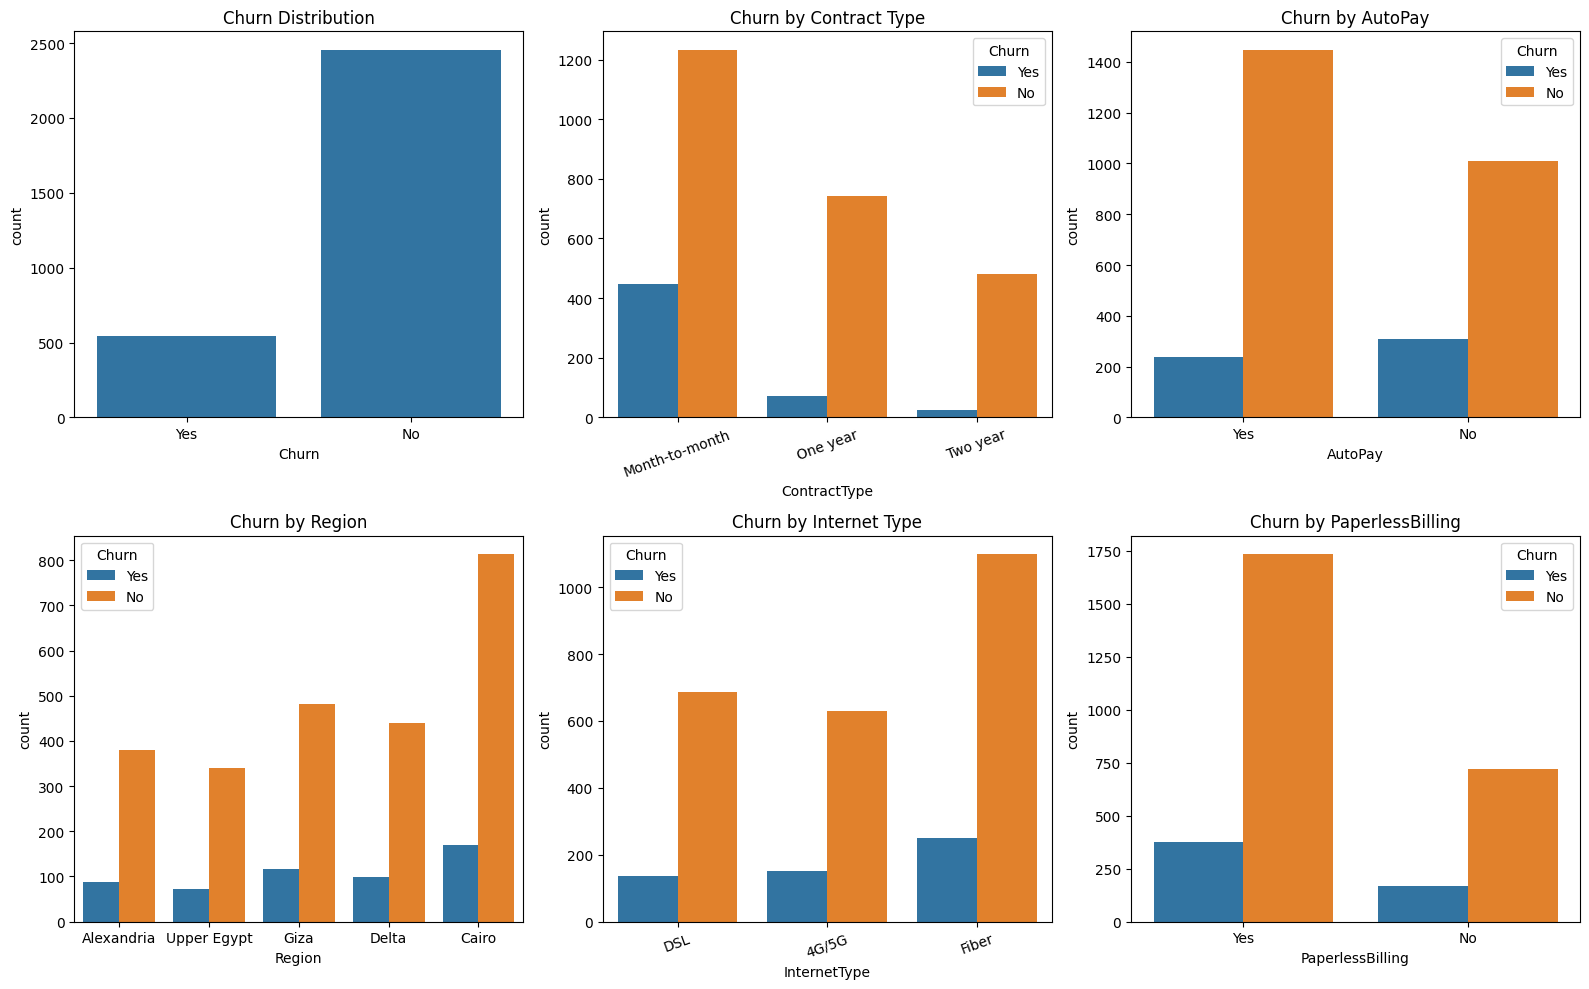

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

sns.countplot(data=df, x="Churn", ax=axes[0, 0])
axes[0, 0].set_title("Churn Distribution")

sns.countplot(data=df, x="ContractType", hue="Churn", ax=axes[0, 1])
axes[0, 1].set_title("Churn by Contract Type")
axes[0, 1].tick_params(axis="x", rotation=20)

sns.countplot(data=df, x="AutoPay", hue="Churn", ax=axes[0, 2])
axes[0, 2].set_title("Churn by AutoPay")

sns.countplot(data=df, x="Region", hue="Churn", ax=axes[1, 0])
axes[1, 0].set_title("Churn by Region")

sns.countplot(data=df, x="InternetType", hue="Churn", ax=axes[1, 1])
axes[1, 1].set_title("Churn by Internet Type")
axes[1, 1].tick_params(axis="x", rotation=20)

sns.countplot(data=df, x="PaperlessBilling", hue="Churn", ax=axes[1, 2])
axes[1, 2].set_title("Churn by PaperlessBilling")

plt.tight_layout()
plt.show()

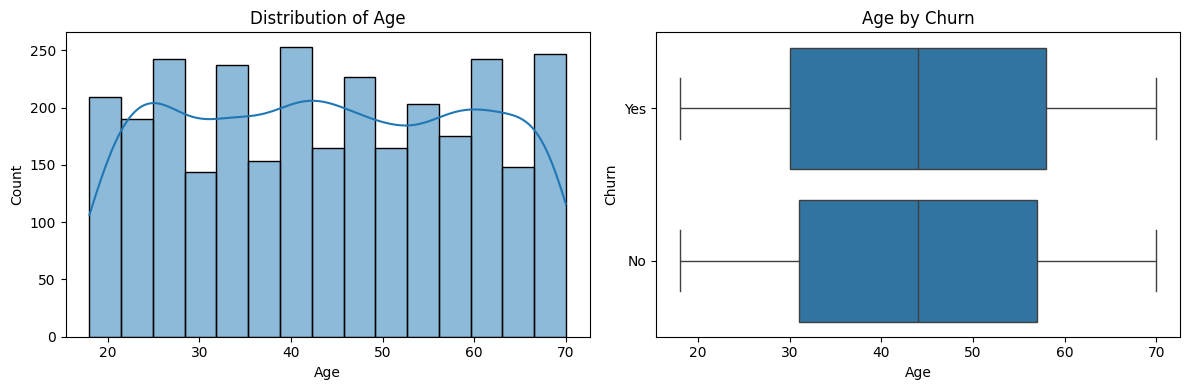

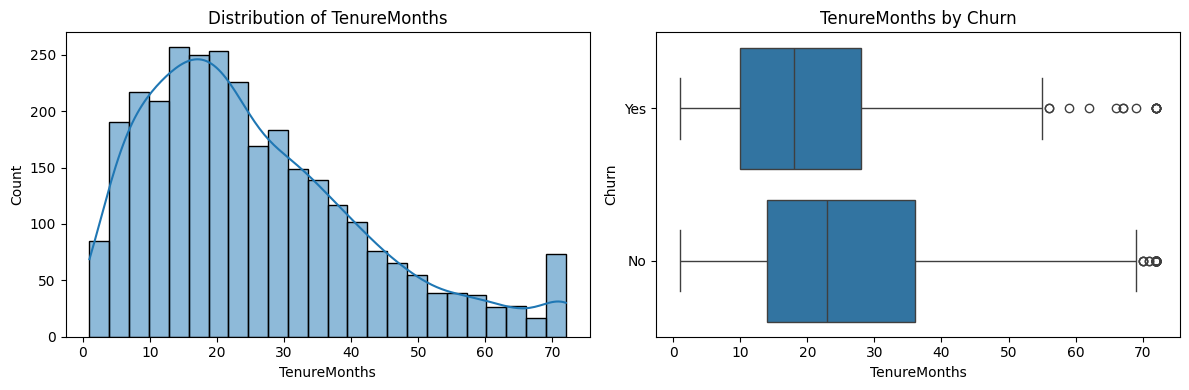

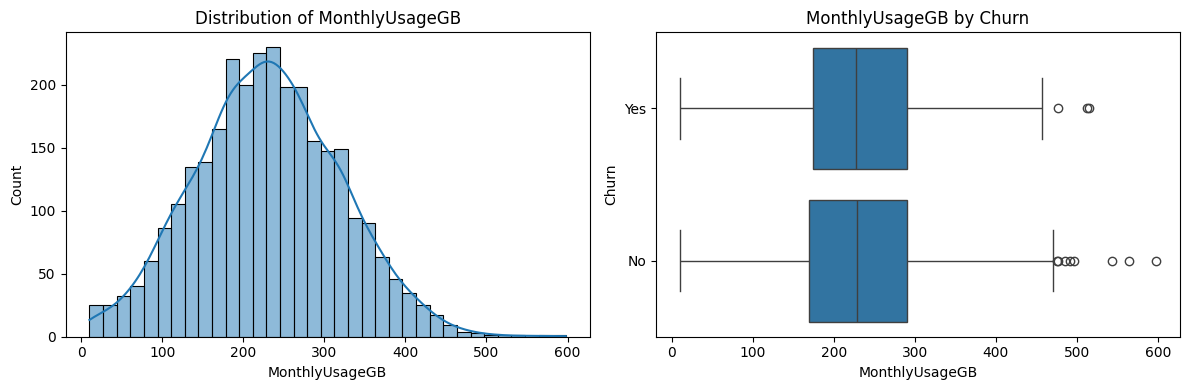

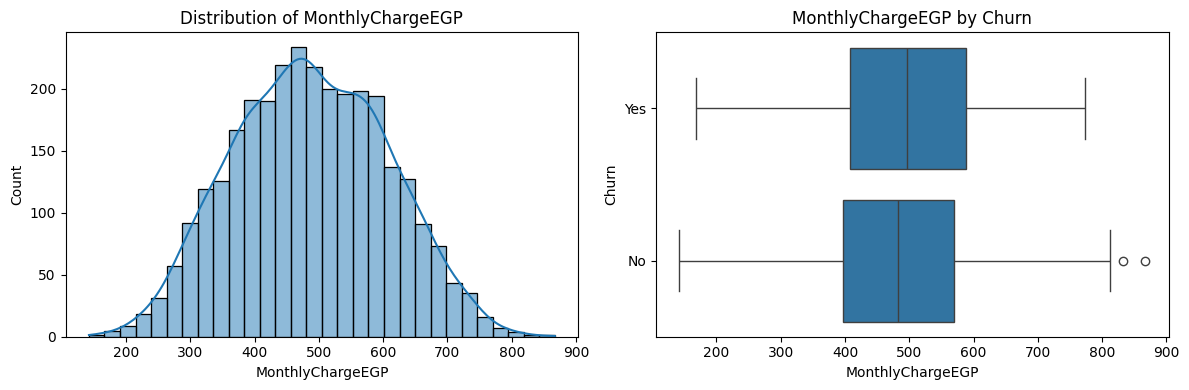

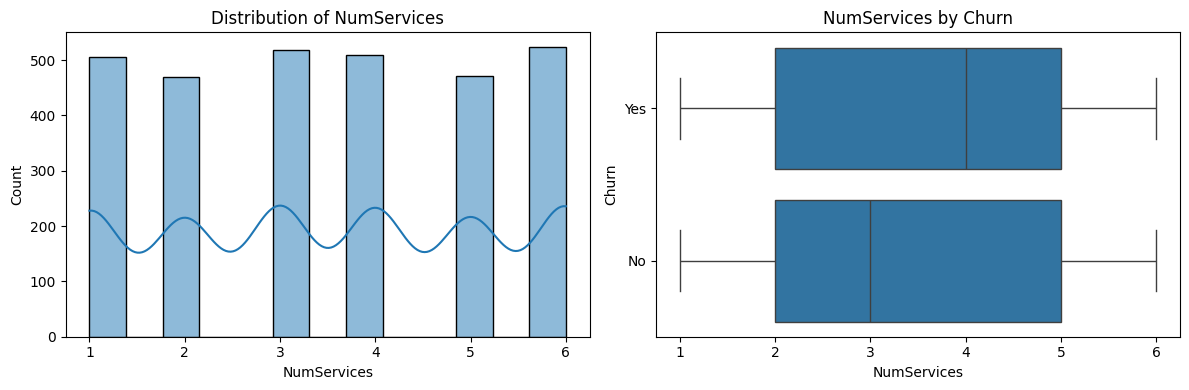

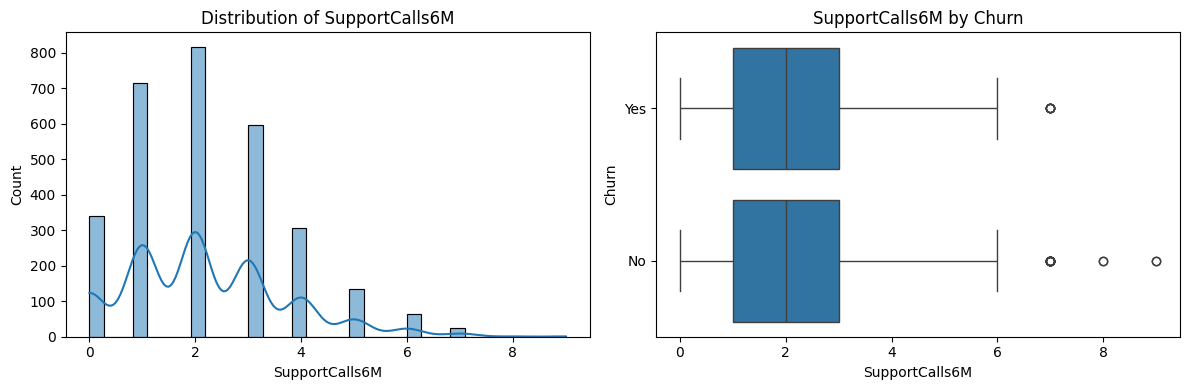

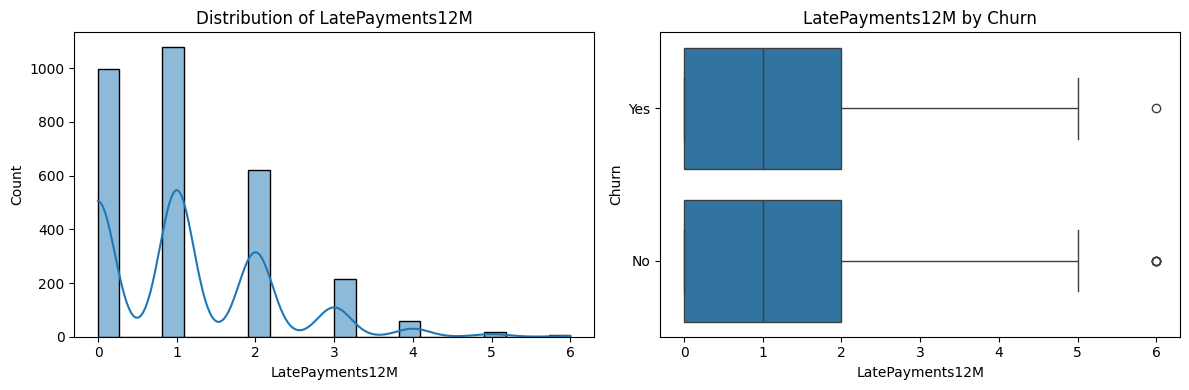

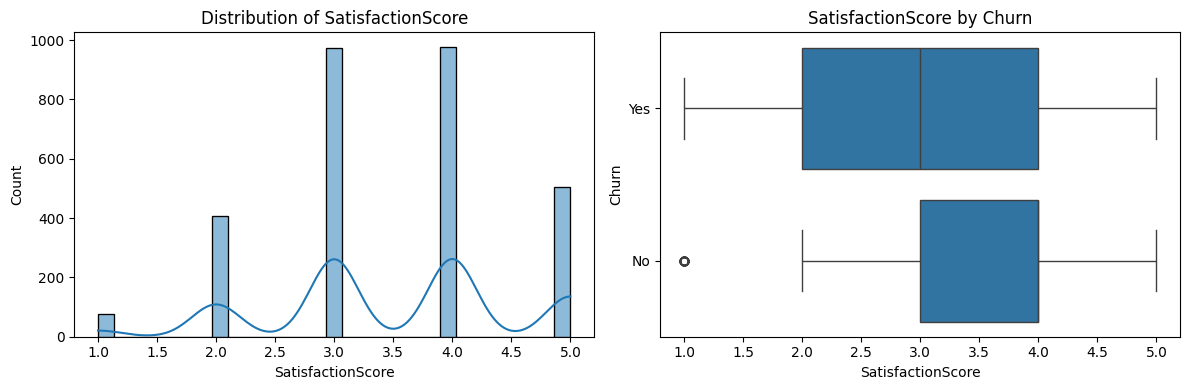

In [13]:
numerical_features_eda = df.select_dtypes(include="number").columns.tolist()
numerical_features_eda.remove("Future12MRevenueEGP")

for col in numerical_features_eda:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(data=df, x=col, kde=True, ax=axes[0])
    axes[0].set_title(f"Distribution of {col}")

    sns.boxplot(data=df, x=col, y="Churn", orient="h", ax=axes[1])
    axes[1].set_title(f"{col} by Churn")

    plt.tight_layout()
    plt.show()

### EDA Summary — at least five observations

1. The dataset contains **3,000 customers and 16 columns**.
2. `CustomerID` is unique for every customer, confirming that it is an identifier rather than a predictive business feature.
3. Missing values are present in `InternetType`, `MonthlyUsageGB`, and `SatisfactionScore`; these will be handled inside the preprocessing pipeline.
4. Churn is not evenly distributed, so accuracy alone can hide poor performance on the minority churn class.
5. `ContractType` and `AutoPay` show visibly different churn patterns; the rate tables above are used to compare the groups rather than relying only on counts.
6. The numerical variables have different scales, which is important for distance- and margin-based algorithms such as KNN and SVM.

### Business Questions

**1. Which column must be excluded because it is an identifier?**  
`CustomerID` must be excluded because it identifies a customer but does not represent a meaningful customer behavior or attribute.

**2. Why should `Future12MRevenueEGP` not be used to predict current churn?**  
It represents a future outcome. Using it as an input would give the churn model information that would not be available at prediction time and would create target leakage.

**3. Is accuracy sufficient for churn prediction?**  
No. Churn is a classification problem where the minority class can be missed even when overall accuracy looks high. Precision, recall, F1, and ROC-AUC should also be considered.

**4. Which algorithms are sensitive to feature scaling?**  
KNN and SVM are especially sensitive because they use distances or geometric margins. Logistic regression and regularized linear models also benefit from standardized features. Tree-based models are generally much less sensitive to scaling.

## B. Data Preprocessing

The train/test split is performed **before** any model fitting. A reusable `ColumnTransformer` handles:

- numerical variables: median imputation → standardization
- categorical variables: most-frequent imputation → one-hot encoding
- `handle_unknown="ignore"` for unseen categories

The transformer is placed inside model pipelines, so each model learns preprocessing only from its training data.

In [14]:
x = df.drop(columns=["CustomerID", "Churn", "Future12MRevenueEGP"])
y_classification = df["Churn"].map({"No": 0, "Yes": 1})
y_regression = df["Future12MRevenueEGP"]

x_train_c, x_test_c, y_train_c, y_test_c = train_test_split(
    x, y_classification,
    test_size=0.20,
    random_state=42,
    stratify=y_classification
)

x_train_r, x_test_r, y_train_r, y_test_r = train_test_split(
    x, y_regression,
    test_size=0.20,
    random_state=42
)

numeric_features = x.select_dtypes(include=np.number).columns.tolist()
categorical_features = x.select_dtypes(exclude=np.number).columns.tolist()

preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), numeric_features),

    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ]), categorical_features)
])

print("Numerical features:", numeric_features)
print("Categorical features:", categorical_features)

Numerical features: ['Age', 'TenureMonths', 'MonthlyUsageGB', 'MonthlyChargeEGP', 'NumServices', 'SupportCalls6M', 'LatePayments12M', 'SatisfactionScore']
Categorical features: ['Region', 'ContractType', 'InternetType', 'PaperlessBilling', 'AutoPay']


## C. Churn Classification

In [15]:
classification_models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=2000),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Support Vector Machine": SVC(random_state=42, probability=True),
    "Naive Bayes": GaussianNB(),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

classification_pipelines = {
    name: Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    for name, model in classification_models.items()
}

In [16]:
cv_class = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

classification_results = []

for name, model in classification_pipelines.items():
    model.fit(x_train_c, y_train_c)
    pred = model.predict(x_test_c)
    prob = model.predict_proba(x_test_c)[:, 1]

    cv_f1 = cross_val_score(model, x_train_c, y_train_c,cv=cv_class, scoring="f1", n_jobs=-1).mean()

    classification_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test_c, pred),
        "Precision": precision_score(y_test_c, pred, zero_division=0),
        "Recall": recall_score(y_test_c, pred, zero_division=0),
        "F1": f1_score(y_test_c, pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test_c, prob),
        "CV F1": cv_f1
    })

classification_results = pd.DataFrame(classification_results).sort_values("CV F1", ascending=False)

classification_results.round(3)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,CV F1
5,Naive Bayes,0.750,0.374,0.560,0.449,0.761,0.436
2,Decision Tree,0.710,0.259,0.321,0.287,0.559,0.310
6,Gradient Boosting,0.808,0.412,0.128,0.196,0.732,0.296
0,Logistic Regression,0.813,0.459,0.156,0.233,0.764,0.260
1,K-Nearest Neighbors,0.792,0.340,0.156,0.214,0.597,0.229
3,Random Forest,0.822,0.542,0.119,0.195,0.718,0.162
4,Support Vector Machine,0.825,0.700,0.064,0.118,0.708,0.085


### Random Forest Tuning

In [17]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=42))
])

rf_params = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [5, 10, 15],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2],
    "model__class_weight": [None, "balanced"]
}

rf_grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_params,
    scoring="f1",
    cv=cv_class,
    n_jobs=-1
)

rf_grid.fit(x_train_c, y_train_c)
rf_tuned = rf_grid.best_estimator_

print("Best Random Forest parameters:")
print(rf_grid.best_params_)

Best Random Forest parameters:
{'model__class_weight': 'balanced', 'model__max_depth': 5, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 200}


In [18]:
rf_pred = rf_tuned.predict(x_test_c)
rf_prob = rf_tuned.predict_proba(x_test_c)[:, 1]

rf_metrics = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"],
    "Score": [
        accuracy_score(y_test_c, rf_pred),
        precision_score(y_test_c, rf_pred, zero_division=0),
        recall_score(y_test_c, rf_pred, zero_division=0),
        f1_score(y_test_c, rf_pred, zero_division=0),
        roc_auc_score(y_test_c, rf_prob)
    ]
})

rf_metrics.round(3)

,Metric,Score
0,Accuracy,0.685
1,Precision,0.332
2,Recall,0.725
3,F1,0.455
4,ROC-AUC,0.754


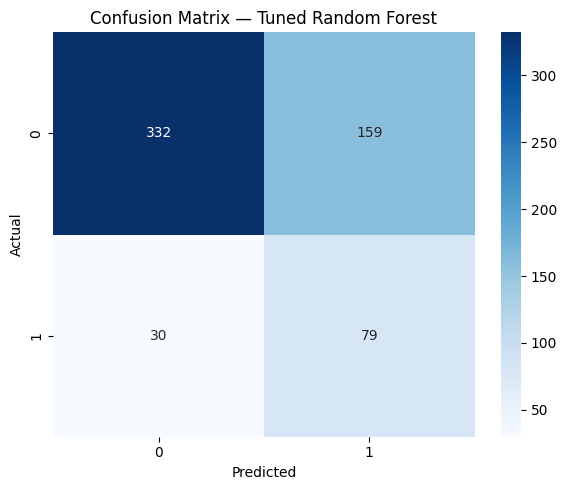

In [19]:
cm = confusion_matrix(y_test_c, rf_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Tuned Random Forest")
plt.tight_layout()
plt.show()

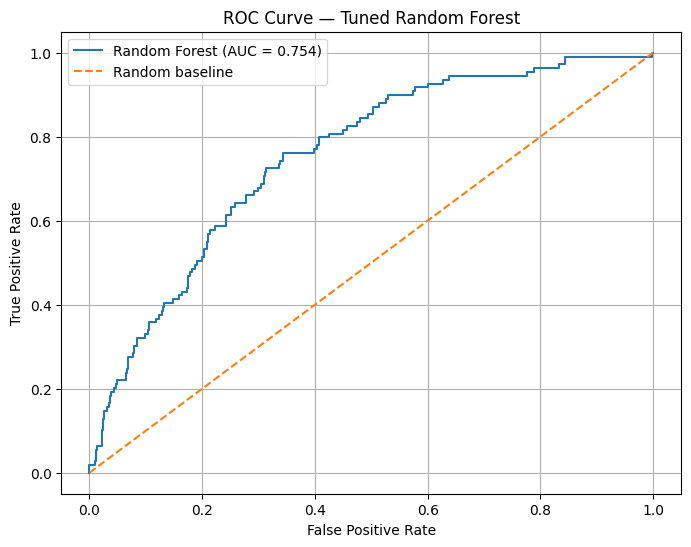

In [20]:
fpr, tpr, _ = roc_curve(y_test_c, rf_prob)
roc_auc = roc_auc_score(y_test_c, rf_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"Random Forest (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], "--", label="Random baseline")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Tuned Random Forest")
plt.legend()
plt.grid()
plt.show()

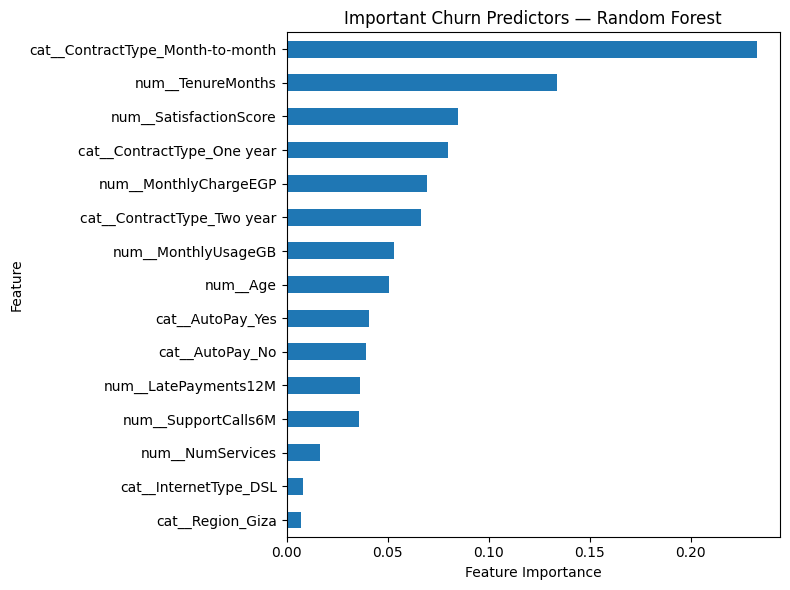

,Importance
cat__ContractType_Month-to-month,0.2325
num__TenureMonths,0.1336
num__SatisfactionScore,0.0846
cat__ContractType_One year,0.0799
num__MonthlyChargeEGP,0.0697
cat__ContractType_Two year,0.0666
num__MonthlyUsageGB,0.0532
num__Age,0.0507
cat__AutoPay_Yes,0.0406
cat__AutoPay_No,0.0392


In [21]:
feature_names = rf_tuned.named_steps["preprocessor"].get_feature_names_out()
importance = rf_tuned.named_steps["model"].feature_importances_

important_features = pd.Series(importance, index=feature_names).sort_values(ascending=False).head(15).sort_values()

plt.figure(figsize=(8, 6))
important_features.plot(kind="barh")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Important Churn Predictors — Random Forest")
plt.tight_layout()
plt.show()

important_features.sort_values(ascending=False).to_frame("Importance").round(4)

### Enhanced Churn Classification — Grid Search + SMOTENC

SMOTENC is included inside the cross-validation pipeline so oversampling is performed only on each training fold. This avoids leakage from synthetic observations into validation folds.

Categorical variables are temporarily ordinal-encoded for SMOTENC, then one-hot encoded after oversampling. Numerical variables are imputed before SMOTENC and standardized afterward.

In [22]:
numeric_pre_smote = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_pre_smote = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
])

pre_smote = ColumnTransformer([
    ("num", numeric_pre_smote, numeric_features),
    ("cat", categorical_pre_smote, categorical_features)
])

num_indices = list(range(len(numeric_features)))
cat_indices = list(range(len(numeric_features), len(numeric_features) + len(categorical_features)))

post_smote = ColumnTransformer([
    ("num", StandardScaler(), num_indices),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_indices)
])

print("SMOTENC categorical indices:", cat_indices)

SMOTENC categorical indices: [8, 9, 10, 11, 12]


In [23]:
grid_models = {
    "Logistic Regression": {
        "model": LogisticRegression(random_state=42, max_iter=2000),
        "params": {
            "model__C": [0.1, 1, 10],
            "model__class_weight": [None, "balanced"]
        }
    },

    "K-Nearest Neighbors": {
        "model": KNeighborsClassifier(),
        "params": {
            "model__n_neighbors": [3, 5, 7],
            "model__weights": ["uniform", "distance"]
        }
    },

    "Decision Tree": {
        "model": DecisionTreeClassifier(random_state=42),
        "params": {
            "model__max_depth": [5, 10, None],
            "model__min_samples_split": [2, 5],
            "model__class_weight": [None, "balanced"]
        }
    },

    "Random Forest": {
        "model": RandomForestClassifier(random_state=42),
        "params": {
            "model__n_estimators": [100, 200],
            "model__max_depth": [5, 10, None],
            "model__min_samples_split": [2, 5],
            "model__class_weight": [None, "balanced"]
        }
    },

    "Support Vector Machine": {
        "model": SVC(random_state=42, probability=True),
        "params": {
            "model__C": [0.1, 1, 10],
            "model__kernel": ["linear", "rbf"]
        }
    },

    "Naive Bayes": {
        "model": GaussianNB(),
        "params": {
            "model__var_smoothing": np.logspace(0, -9, 5)
        }
    },

    "Gradient Boosting": {
        "model": GradientBoostingClassifier(random_state=42),
        "params": {
            "model__n_estimators": [100, 200],
            "model__learning_rate": [0.05, 0.1],
            "model__max_depth": [3, 5]
        }
    }
}

tuned_classification_models = {}
tuned_classification_results = []

for name, info in grid_models.items():

    pipeline = ImbPipeline([
        ("pre_smote", pre_smote),
        ("smote", SMOTENC(categorical_features=cat_indices, random_state=42)),
        ("post_smote", post_smote),
        ("model", info["model"])
    ])

    grid = GridSearchCV(
        estimator=pipeline,
        param_grid=info["params"],
        scoring="f1",
        cv=cv_class,
        n_jobs=-1
    )

    grid.fit(x_train_c, y_train_c)

    best_model = grid.best_estimator_
    tuned_classification_models[name] = best_model

    pred = best_model.predict(x_test_c)
    prob = best_model.predict_proba(x_test_c)[:, 1]

    tuned_classification_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test_c, pred),
        "Precision": precision_score(y_test_c, pred, zero_division=0),
        "Recall": recall_score(y_test_c, pred, zero_division=0),
        "F1": f1_score(y_test_c, pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test_c, prob),
        "CV Best F1": grid.best_score_
    })

tuned_classification_results = pd.DataFrame(tuned_classification_results).sort_values("CV Best F1", ascending=False)

tuned_classification_results.round(3)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,CV Best F1
0,Logistic Regression,0.695,0.325,0.633,0.430,0.753,0.456
4,Support Vector Machine,0.675,0.325,0.734,0.451,0.752,0.455
3,Random Forest,0.702,0.325,0.596,0.421,0.740,0.453
5,Naive Bayes,0.610,0.294,0.817,0.432,0.728,0.421
6,Gradient Boosting,0.782,0.394,0.376,0.385,0.743,0.404
1,K-Nearest Neighbors,0.567,0.225,0.569,0.323,0.615,0.398
2,Decision Tree,0.733,0.353,0.560,0.433,0.722,0.388


### Confusion Matrices — All Tuned Classification Models

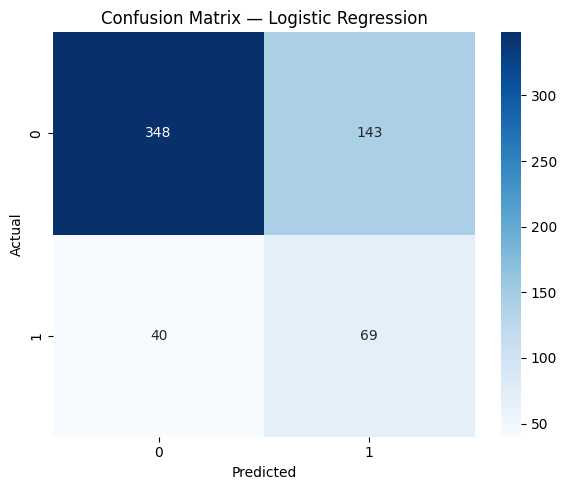

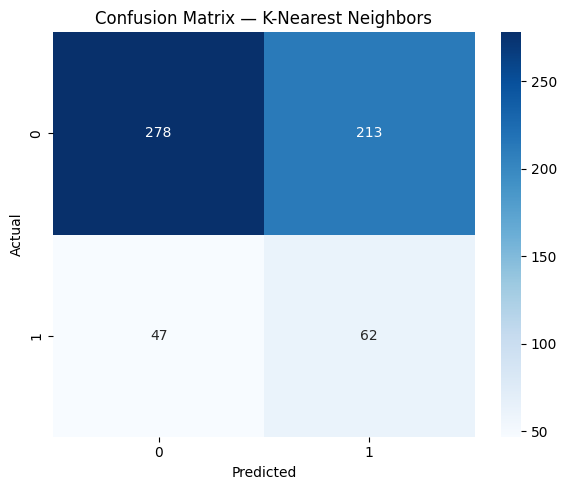

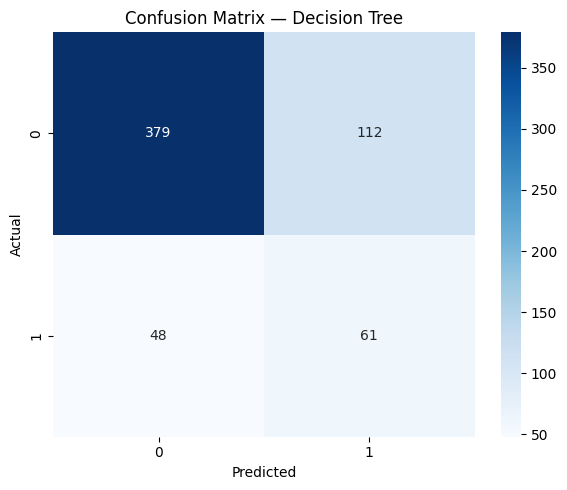

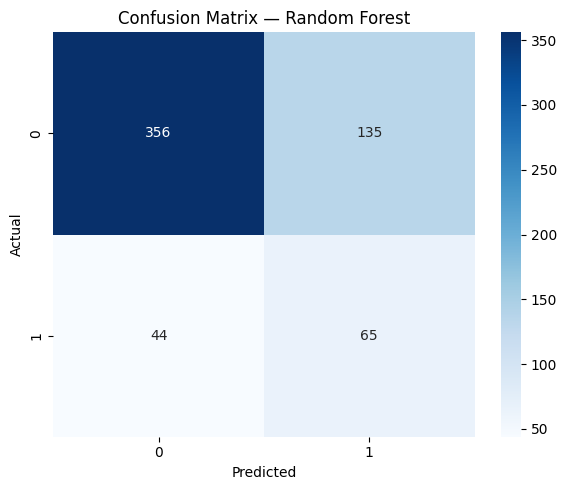

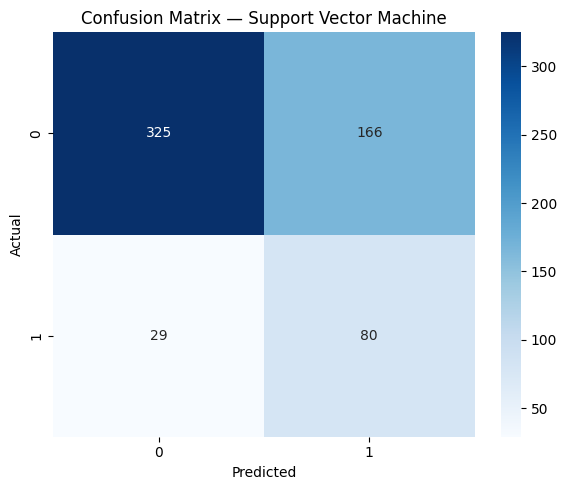

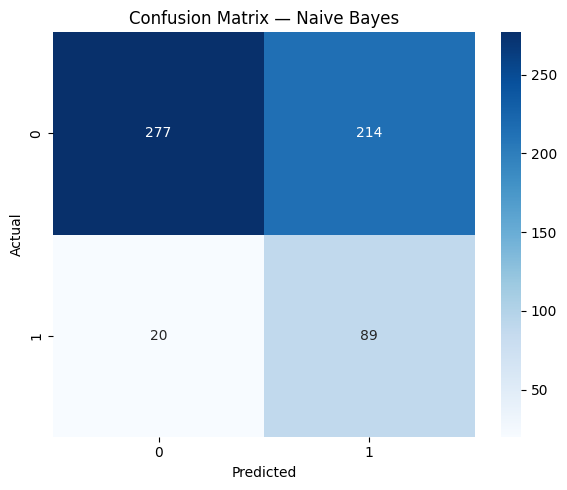

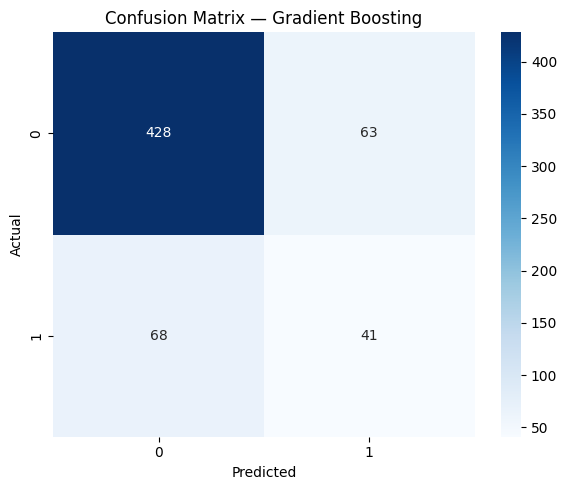

In [24]:
for name, model in tuned_classification_models.items():
    pred = model.predict(x_test_c)
    cm = confusion_matrix(y_test_c, pred)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix — {name}")
    plt.tight_layout()
    plt.show()

### ROC Curve — All Tuned Classification Models

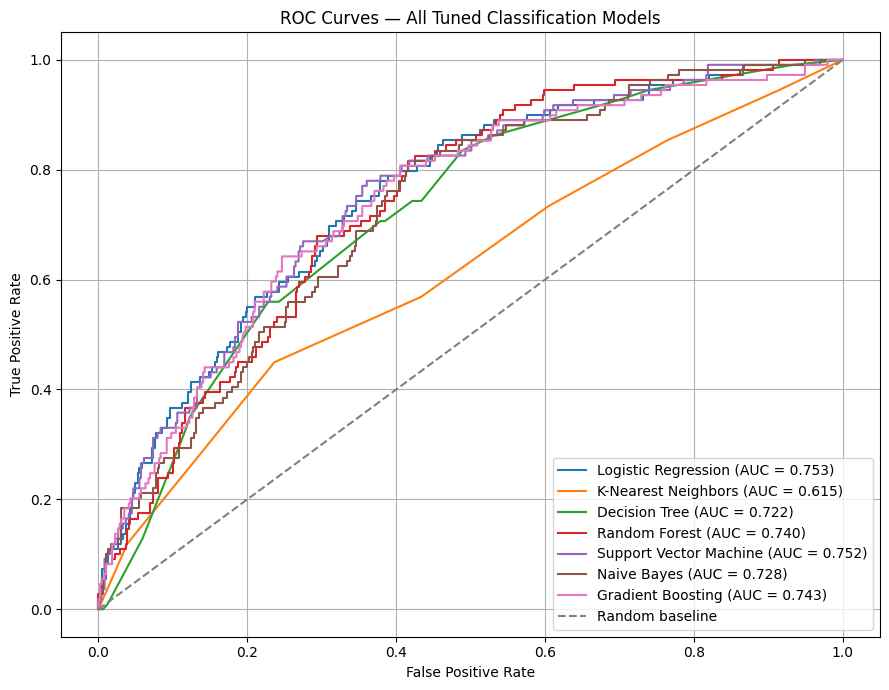

In [25]:
plt.figure(figsize=(9, 7))

for name, model in tuned_classification_models.items():
    prob = model.predict_proba(x_test_c)[:, 1]
    fpr, tpr, _ = roc_curve(y_test_c, prob)
    roc_auc = roc_auc_score(y_test_c, prob)

    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], "--", label="Random baseline")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — All Tuned Classification Models")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

### Final Tuned Random Forest — Important Churn Predictors

In [26]:
rf_tuned = tuned_classification_models["Random Forest"]

rf_pred = rf_tuned.predict(x_test_c)
rf_prob = rf_tuned.predict_proba(x_test_c)[:, 1]

rf_metrics = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"],
    "Score": [
        accuracy_score(y_test_c, rf_pred),
        precision_score(y_test_c, rf_pred, zero_division=0),
        recall_score(y_test_c, rf_pred, zero_division=0),
        f1_score(y_test_c, rf_pred, zero_division=0),
        roc_auc_score(y_test_c, rf_prob)
    ]
})

rf_metrics.round(3)

,Metric,Score
0,Accuracy,0.702
1,Precision,0.325
2,Recall,0.596
3,F1,0.421
4,ROC-AUC,0.740


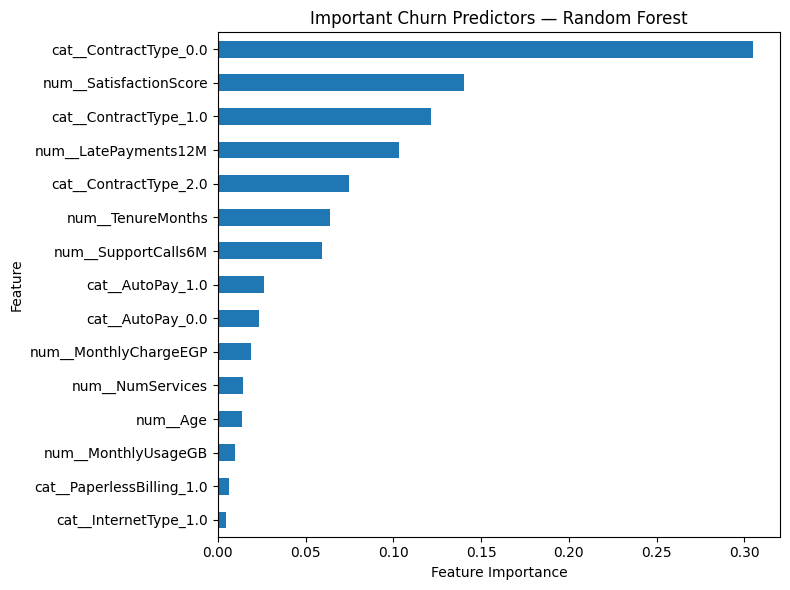

,Importance
cat__ContractType_0.0,0.3050
num__SatisfactionScore,0.1405
cat__ContractType_1.0,0.1215
num__LatePayments12M,0.1032
cat__ContractType_2.0,0.0745
num__TenureMonths,0.0641
num__SupportCalls6M,0.0594
cat__AutoPay_1.0,0.0263
cat__AutoPay_0.0,0.0237
num__MonthlyChargeEGP,0.0187


In [27]:
feature_names = numeric_features + categorical_features

importance = rf_tuned.named_steps["model"].feature_importances_

feature_names = rf_tuned.named_steps["post_smote"].get_feature_names_out(feature_names)

important_features = pd.Series(importance,index=feature_names).sort_values(ascending=False).head(15).sort_values()

plt.figure(figsize=(8, 6))
important_features.plot(kind="barh")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Important Churn Predictors — Random Forest")
plt.tight_layout()
plt.show()

important_features.sort_values(ascending=False).to_frame("Importance").round(4)

### Churn Threshold Analysis

A lower threshold catches more potential churners, while a higher threshold creates a smaller, more selective outreach group. The threshold should therefore be chosen using the business cost of missed churn versus unnecessary retention contact.

In [28]:
threshold_rows = []

for threshold in [0.35, 0.50, 0.70]:
    pred_threshold = (rf_prob >= threshold).astype(int)

    threshold_rows.append({
        "Threshold": threshold,
        "Predicted Churn %": pred_threshold.mean(),
        "Precision": precision_score(y_test_c, pred_threshold, zero_division=0),
        "Recall": recall_score(y_test_c, pred_threshold, zero_division=0),
        "F1": f1_score(y_test_c, pred_threshold, zero_division=0)
    })

pd.DataFrame(threshold_rows).round(3)

,Threshold,Predicted Churn %,Precision,Recall,F1
0,0.35,0.517,0.290,0.826,0.430
1,0.50,0.333,0.325,0.596,0.421
2,0.70,0.053,0.406,0.119,0.184


## D. Future 12-Month Revenue Regression

Target: `Future12MRevenueEGP`.

`Churn` is not used as a feature because it is another outcome in this dataset. The regression models use the same customer attributes available before the future revenue outcome.

The test set remains untouched during model selection. Cross-validation on the training set is used to compare models before the final test evaluation.

In [29]:
regression_models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(random_state=42),
    "Lasso": Lasso(random_state=42),
    "KNN Regressor": KNeighborsRegressor(),
    "Decision Tree Regressor": DecisionTreeRegressor(random_state=42),
    "Random Forest Regressor": RandomForestRegressor(random_state=42),
    "Gradient Boosting Regressor": GradientBoostingRegressor(random_state=42)
}

regression_pipelines = {
    name: Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    for name, model in regression_models.items()
}

In [30]:
cv_reg = KFold(n_splits=5, shuffle=True, random_state=42)

regression_results = []

for name, model in regression_pipelines.items():
    cv_r2 = cross_val_score(model, x_train_r, y_train_r,cv=cv_reg, scoring="r2", n_jobs=-1).mean()

    model.fit(x_train_r, y_train_r)
    pred = model.predict(x_test_r)

    regression_results.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test_r, pred),
        "RMSE": np.sqrt(mean_squared_error(y_test_r, pred)),
        "R²": r2_score(y_test_r, pred),
        "CV R²": cv_r2
    })

regression_results = pd.DataFrame(regression_results).sort_values("CV R²", ascending=False)

regression_results.round(3)

,Model,MAE,RMSE,R²,CV R²
6,Gradient Boosting Regressor,368.560,464.972,0.897,0.902
2,Lasso,378.672,475.086,0.892,0.899
1,Ridge,378.417,474.915,0.892,0.899
0,Linear Regression,378.427,474.928,0.892,0.899
5,Random Forest Regressor,393.555,496.139,0.883,0.893
4,Decision Tree Regressor,537.060,683.954,0.777,0.792
3,KNN Regressor,619.291,783.499,0.707,0.745


In [31]:
best_reg_name = regression_results.iloc[0]["Model"]
best_reg_model = regression_pipelines[best_reg_name]

best_reg_pred = best_reg_model.predict(x_test_r)

print(f"Selected revenue model based on training CV R²: {best_reg_name}")
print(f"Test MAE: {mean_absolute_error(y_test_r, best_reg_pred):,.2f} EGP")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test_r, best_reg_pred)):,.2f} EGP")
print(f"Test R²: {r2_score(y_test_r, best_reg_pred):.3f}")

Selected revenue model based on training CV R²: Gradient Boosting Regressor
Test MAE: 368.56 EGP
Test RMSE: 464.97 EGP
Test R²: 0.897


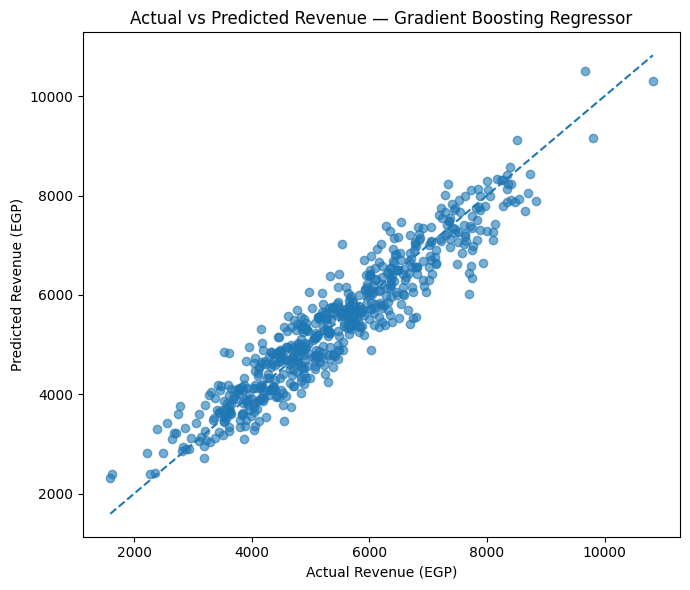

In [32]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test_r, best_reg_pred, alpha=0.6)

lims = [min(y_test_r.min(), best_reg_pred.min()),max(y_test_r.max(), best_reg_pred.max())]

plt.plot(lims, lims, "--")
plt.xlabel("Actual Revenue (EGP)")
plt.ylabel("Predicted Revenue (EGP)")
plt.title(f"Actual vs Predicted Revenue — {best_reg_name}")
plt.tight_layout()
plt.show()

## E. Customer Segmentation

Segmentation uses:

`TenureMonths`, `MonthlyUsageGB`, `MonthlyChargeEGP`, `NumServices`, `SupportCalls6M`, `LatePayments12M`, and `SatisfactionScore`.

Missing values are median-imputed and all variables are standardized because the clustering methods are distance-based.

In [33]:
seg_cols = [
    "TenureMonths",
    "MonthlyUsageGB",
    "MonthlyChargeEGP",
    "NumServices",
    "SupportCalls6M",
    "LatePayments12M",
    "SatisfactionScore"
]

seg_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

z_seg = seg_pipeline.fit_transform(df[seg_cols])
z_seg = pd.DataFrame(z_seg, columns=seg_cols, index=df.index)

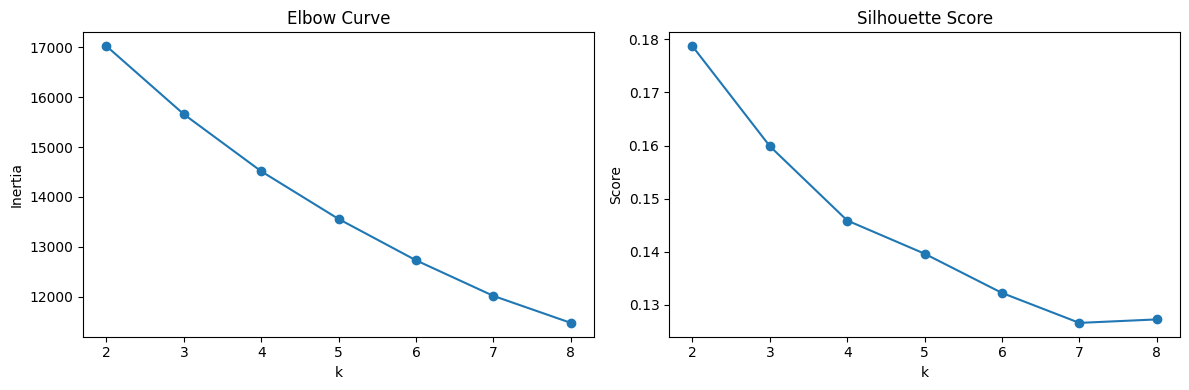

Selected k = 2 using the highest silhouette score.


,Inertia,Silhouette
k,,
2,17022.123,0.179
3,15656.868,0.160
4,14513.831,0.146
5,13557.871,0.140
6,12730.019,0.132
7,12017.109,0.127
8,11476.539,0.127


In [34]:
k_rows = []

for k_value in range(2, 9):
    model = KMeans(n_clusters=k_value, n_init=10, random_state=42)
    labels = model.fit_predict(z_seg)

    k_rows.append({
        "k": k_value,
        "Inertia": model.inertia_,
        "Silhouette": silhouette_score(z_seg, labels)
    })

k_table = pd.DataFrame(k_rows).set_index("k")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(k_table.index, k_table["Inertia"], "o-")
axes[0].set_title("Elbow Curve")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia")

axes[1].plot(k_table.index, k_table["Silhouette"], "o-")
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Score")

plt.tight_layout()
plt.show()

k = int(k_table["Silhouette"].idxmax())
print(f"Selected k = {k} using the highest silhouette score.")
display(k_table.round(3))

In [35]:
kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
kmeans_labels = kmeans.fit_predict(z_seg)

df["KMeansCluster"] = kmeans_labels

profile = df.groupby("KMeansCluster")[seg_cols].mean()
profile["Customers"] = df["KMeansCluster"].value_counts().sort_index()
profile["ChurnRate"] = df.groupby("KMeansCluster")["Churn"].apply(lambda s: (s == "Yes").mean())
profile["AvgFutureRevenue"] = df.groupby("KMeansCluster")["Future12MRevenueEGP"].mean()

profile.round(2)

,TenureMonths,MonthlyUsageGB,MonthlyChargeEGP,NumServices,SupportCalls6M,LatePayments12M,SatisfactionScore,Customers,ChurnRate,AvgFutureRevenue
KMeansCluster,,,,,,,,,,
0,25.13,243.09,581.44,4.94,2.26,1.11,3.49,1490,0.20,6351.77
1,25.94,217.44,394.50,2.11,2.15,1.11,3.48,1510,0.16,4383.66


In [36]:
cluster_centers = pd.DataFrame(kmeans.cluster_centers_, columns=seg_cols)

def name_cluster(row):
    if row["SatisfactionScore"] < -0.6 and (row["SupportCalls6M"] > 0.5 or row["LatePayments12M"] > 0.5):
        return "At-Risk Customers"
    if row["TenureMonths"] < -0.5 and row["NumServices"] < -0.3:
        return "New / Low-Engagement"
    if row["MonthlyChargeEGP"] > 0.5 and (row["MonthlyUsageGB"] > 0.4 or row["NumServices"] > 0.4):
        return "High-Value Users"
    if row["LatePayments12M"] > 0.6:
        return "Payment-Risk Customers"
    if row["TenureMonths"] > 0.5 and row["SatisfactionScore"] > 0.3:
        return "Loyal & Engaged"
    return "Steady Core Customers"

cluster_names = {}
used_names = set()

for cluster_id, row in cluster_centers.iterrows():
    proposed = name_cluster(row)

    if proposed in used_names:
        proposed = f"{proposed} ({cluster_id})"

    cluster_names[cluster_id] = proposed
    used_names.add(proposed)

df["Segment"] = df["KMeansCluster"].map(cluster_names)
profile["Segment"] = profile.index.map(cluster_names)

display(profile.round(2))

,TenureMonths,MonthlyUsageGB,MonthlyChargeEGP,NumServices,SupportCalls6M,LatePayments12M,SatisfactionScore,Customers,ChurnRate,AvgFutureRevenue,Segment
KMeansCluster,,,,,,,,,,,
0,25.13,243.09,581.44,4.94,2.26,1.11,3.49,1490,0.20,6351.77,High-Value Users
1,25.94,217.44,394.50,2.11,2.15,1.11,3.48,1510,0.16,4383.66,Steady Core Customers


### Agglomerative Clustering and DBSCAN

Agglomerative clustering is run with the same selected `k` so its result can be compared with K-Means.

For DBSCAN, label **`-1` means noise**: the customer is not assigned to a sufficiently dense cluster under the selected `eps` and `min_samples`. It does **not** mean fraud or bad behavior.

In [37]:
agg_labels = AgglomerativeClustering(n_clusters=k, linkage="ward").fit_predict(z_seg)

min_samples = 10

nearest_distances = (NearestNeighbors(n_neighbors=min_samples).fit(z_seg).kneighbors(z_seg)[0][:, -1])

eps = float(np.percentile(nearest_distances, 90))

dbscan = DBSCAN(eps=eps, min_samples=min_samples)
db_labels = dbscan.fit_predict(z_seg)

def cluster_silhouette(labels):
    mask = labels != -1
    unique = np.unique(labels[mask])

    if len(unique) < 2:
        return np.nan

    return silhouette_score(z_seg.loc[mask], labels[mask])

comparison = pd.DataFrame({
    "Clusters": [
        len(np.unique(kmeans_labels)),
        len(np.unique(agg_labels)),
        len(set(db_labels)) - (1 if -1 in db_labels else 0)
    ],
    "Noise Points": [
        0,
        0,
        int((db_labels == -1).sum())
    ],
    "Silhouette": [
        silhouette_score(z_seg, kmeans_labels),
        silhouette_score(z_seg, agg_labels),
        cluster_silhouette(db_labels)
    ],
    "ARI vs K-Means": [
        1.0,
        adjusted_rand_score(kmeans_labels, agg_labels),
        adjusted_rand_score(kmeans_labels, db_labels)
    ]
}, index=["K-Means", "Agglomerative", "DBSCAN"])

print(f"DBSCAN eps = {eps:.3f}, min_samples = {min_samples}")
comparison.round(2)

DBSCAN eps = 1.686, min_samples = 10


,Clusters,Noise Points,Silhouette,ARI vs K-Means
K-Means,2,0,0.18,1.0
Agglomerative,2,0,0.11,0.3
DBSCAN,1,70,NaN,0.0


### Segmentation Interpretation

A high silhouette score is useful evidence of separation, but it is not enough by itself. A business-useful segment should also be interpretable, sufficiently large, reasonably stable, and connected to meaningful customer behavior or value.

The cluster profile table above should be used to describe the practical differences between segments.

## F. PCA & Anomaly Detection

Explained variance ratio: [0.26 0.15]
PC1 + PC2 explain 41.2% of the variance.


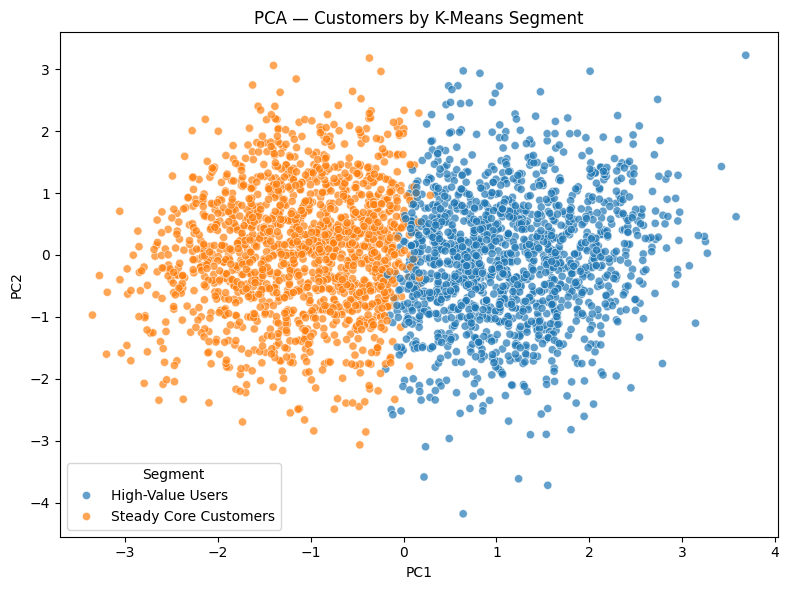

,PC1,PC2
TenureMonths,-0.02,-0.02
MonthlyUsageGB,0.22,0.59
MonthlyChargeEGP,0.71,-0.00
NumServices,0.67,-0.21
SupportCalls6M,0.03,0.32
LatePayments12M,0.01,-0.55
SatisfactionScore,0.02,0.44


In [38]:
pca = PCA(n_components=2, random_state=42)
pcs = pca.fit_transform(z_seg)

df["PC1"] = pcs[:, 0]
df["PC2"] = pcs[:, 1]

print("Explained variance ratio:", pca.explained_variance_ratio_.round(2))
print(f"PC1 + PC2 explain {pca.explained_variance_ratio_.sum():.1%} of the variance.")

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="PC1", y="PC2",hue="Segment", alpha=0.7, s=35)
plt.title("PCA — Customers by K-Means Segment")
plt.tight_layout()
plt.show()

loadings = pd.DataFrame(
    pca.components_.T,
    index=seg_cols,
    columns=["PC1", "PC2"]
)

loadings.round(2)

In [39]:
iso = IsolationForest(contamination=0.03,random_state=42)

df["AnomalyFlag"] = (iso.fit_predict(z_seg) == -1).astype(int)
df["AnomalyScore"] = iso.decision_function(z_seg)

z_df = pd.DataFrame(z_seg, columns=seg_cols, index=df.index)

def anomaly_reason(index):
    values = z_df.loc[index].abs().sort_values(ascending=False).head(2)

    return "; ".join(f"{'high' if z_df.loc[index, col] > 0 else 'low'} {col}"for col in values.index)

anomalies = df[df["AnomalyFlag"] == 1].copy()
anomalies["WhyUnusual"] = [
    anomaly_reason(i) for i in anomalies.index
]

anomalies = anomalies.sort_values("AnomalyScore").head(10)

print(f"Isolation Forest flagged {df['AnomalyFlag'].sum()} customers ({df['AnomalyFlag'].mean():.1%}).")

display(
    anomalies[
        [
            "CustomerID", "Segment", "TenureMonths",
            "MonthlyUsageGB", "MonthlyChargeEGP",
            "SupportCalls6M", "LatePayments12M",
            "SatisfactionScore", "AnomalyScore",
            "WhyUnusual"
        ]
    ]
)

print("An anomaly is an unusual customer profile. It is not automatically fraud.")

Isolation Forest flagged 90 customers (3.0%).


,CustomerID,Segment,TenureMonths,MonthlyUsageGB,MonthlyChargeEGP,SupportCalls6M,LatePayments12M,SatisfactionScore,AnomalyScore,WhyUnusual
2045,CUST-02046,High-Value Users,16,443.6,743.84,0,4,5.0,-0.070543,high LatePayments12M; high MonthlyUsageGB
1311,CUST-01312,Steady Core Customers,56,69.4,231.29,1,0,1.0,-0.069434,low SatisfactionScore; low MonthlyChargeEGP
1948,CUST-01949,Steady Core Customers,46,95.5,292.09,6,3,5.0,-0.062481,high SupportCalls6M; high LatePayments12M
1288,CUST-01289,High-Value Users,72,286.0,485.50,5,5,3.0,-0.057637,high LatePayments12M; high TenureMonths
1316,CUST-01317,High-Value Users,56,133.0,552.62,6,0,1.0,-0.052570,high SupportCalls6M; low SatisfactionScore
965,CUST-00966,High-Value Users,6,325.6,748.06,0,0,1.0,-0.050205,low SatisfactionScore; high MonthlyChargeEGP
1541,CUST-01542,Steady Core Customers,42,125.9,319.34,5,5,3.0,-0.046042,high LatePayments12M; high SupportCalls6M
460,CUST-00461,Steady Core Customers,24,251.9,325.84,8,0,1.0,-0.044682,high SupportCalls6M; low SatisfactionScore
995,CUST-00996,High-Value Users,10,178.4,629.68,6,5,3.0,-0.043806,high LatePayments12M; high SupportCalls6M
913,CUST-00914,Steady Core Customers,37,221.6,456.92,0,4,1.0,-0.041721,high LatePayments12M; low SatisfactionScore


An anomaly is an unusual customer profile. It is not automatically fraud.


## G. Customer 360 Integration

For the final Customer 360 table, the churn and revenue predictions below are generated with cross-validation on the full dataset using the selected model structures. This avoids using the target value of the same customer to create an apparently perfect prediction.

### Retention-priority rule

A customer is marked as retention priority when:

- churn probability is at least **0.50**, and
- predicted 12-month revenue is at or above the **median predicted revenue**.

This rule combines risk and customer value. In a real deployment, the threshold should be adjusted using the actual cost of retention offers and the value of prevented churn.

In [40]:
final_churn_model = rf_tuned
final_revenue_model = best_reg_model

churn_oof = cross_val_predict(final_churn_model,x,y_classification,cv=cv_class,method="predict_proba",n_jobs=-1)[:, 1]

revenue_oof = cross_val_predict(final_revenue_model,x,y_regression,cv=cv_reg,method="predict",n_jobs=-1)

customer_360 = pd.DataFrame({
    "CustomerID": df["CustomerID"],
    "ChurnProbability": churn_oof.round(4),
    "PredictedRevenue12M_EGP": np.maximum(revenue_oof, 0).round(2),
    "CustomerSegment": df["Segment"],
    "AnomalyFlag": df["AnomalyFlag"]
})

revenue_cutoff = customer_360["PredictedRevenue12M_EGP"].median()

customer_360["RetentionPriority"] = ((customer_360["ChurnProbability"] >= 0.50) &(customer_360["PredictedRevenue12M_EGP"] >= revenue_cutoff)).astype(int)

Path("../outputs").mkdir(exist_ok=True)

output_path = Path("../outputs/customer_360_predictions.csv")
customer_360.to_csv(output_path, index=False)

print(f"Saved: {output_path}")
print(f"Retention-priority customers: {customer_360['RetentionPriority'].sum()} ({customer_360['RetentionPriority'].mean():.1%})")

display(customer_360.head(10))

Saved: ..\outputs\customer_360_predictions.csv
Retention-priority customers: 371 (12.4%)


,CustomerID,ChurnProbability,PredictedRevenue12M_EGP,CustomerSegment,AnomalyFlag,RetentionPriority
0,CUST-00001,0.3668,5979.58,High-Value Users,0,0
1,CUST-00002,0.4153,4236.36,Steady Core Customers,0,0
2,CUST-00003,0.5160,4046.40,Steady Core Customers,0,0
3,CUST-00004,0.4323,4148.14,Steady Core Customers,0,0
4,CUST-00005,0.5345,4597.35,Steady Core Customers,0,0
5,CUST-00006,0.1088,5408.02,Steady Core Customers,0,0
6,CUST-00007,0.6757,3887.06,Steady Core Customers,0,0
7,CUST-00008,0.1568,5554.16,Steady Core Customers,0,0
8,CUST-00009,0.1703,3262.58,Steady Core Customers,0,0
9,CUST-00010,0.1734,4267.59,Steady Core Customers,0,0


## Business Recommendations

1. Use churn probability to prioritize proactive retention outreach rather than treating all customers equally.
2. Combine churn risk with predicted 12-month value so retention resources can be focused where intervention may have meaningful value.
3. Use segment profiles to design different actions for high-value, low-engagement, loyal, payment-risk, and at-risk customers.
4. Review anomaly cases manually before taking action; unusual behavior should trigger investigation, not an automatic fraud or penalty decision.
5. Monitor model performance, calibration, segment stability, and data drift after deployment, and retrain when performance or customer behavior changes materially.

## Challenge Questions

**1. What changes when the churn threshold moves from 0.50 to 0.35 or 0.70?**  
A lower threshold labels more customers as likely to churn, usually increasing recall while reducing precision. A higher threshold labels fewer customers, usually increasing precision while reducing recall. The threshold table above shows the actual trade-off.

**2. When is recall more important than precision for churn?**  
Recall is more important when missing a genuine churner is more costly than contacting some customers who would not have churned.

**3. Why must `CustomerID` be excluded from model features?**  
It is an identifier rather than a meaningful customer characteristic. Including it can create meaningless patterns and reduce generalization.

**4. Why is one-hot encoding required?**  
Categorical values such as region and contract type are labels, not quantities. One-hot encoding converts them into binary features without creating a false numerical ordering.

**5. Which algorithms are most sensitive to scaling?**  
KNN and SVM are especially sensitive. Logistic regression and regularized linear models also benefit from scaling. Tree-based models are generally less sensitive.

**6. Can a cluster be considered useful only because its silhouette score is high?**  
No. Business usefulness also depends on interpretability, stability, size, and whether the segments support meaningful actions.

**7. How would you monitor model drift after deployment?**  
Monitor feature distributions, missingness, categorical frequencies, prediction distributions, calibration, and—when labels become available—precision, recall, F1, ROC-AUC, MAE, RMSE, and R² over time.

**8. What risks exist if retention offers are automatically assigned by a model?**  
Risks include unfair treatment, false positives, unnecessary discounts, privacy concerns, feedback loops, and over-reliance on imperfect predictions. High-impact actions should include monitoring and appropriate human review.

## Final Checklist

- CustomerID excluded from model features
- Future12MRevenueEGP excluded from churn prediction
- Reusable preprocessing pipeline
- Median numerical imputation
- Most-frequent categorical imputation
- Standardization
- One-hot encoding with `handle_unknown="ignore"`
- Stratified churn train/test split
- Seven classification algorithms compared
- Accuracy, Precision, Recall, F1, and ROC-AUC reported
- Confusion matrix and ROC curve included
- Random Forest tuned with GridSearchCV
- Important churn predictors identified
- Seven regression algorithms compared
- MAE, RMSE, and R² reported
- Actual-vs-predicted revenue plot included
- K-Means tested across several values of k
- Inertia and silhouette score reported
- K-Means cluster profiles and business names included
- Agglomerative Clustering and DBSCAN compared
- DBSCAN label -1 explained
- PCA explained variance and PC1/PC2 visualization included
- At least ten anomalies investigated
- Anomalies are not automatically treated as fraud
- Customer 360 output saved to `outputs/customer_360_predictions.csv`
- Retention-priority rule explained
- Business recommendations included
- Challenge questions answered
- Enhanced classification: GridSearchCV for all 7 models, SMOTENC inside CV, confusion matrices for all models, and combined ROC curve.